In [17]:
#install.packages("prospectr")
install.packages("resemble")
#install.packages("caret")
#install.packages("pls")
#install.packages("randomForest")
#install.packages("ranger")

Installing package into ‘/home/camahubuntu/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)



Warning message in install.packages("resemble"):
“installation of package ‘resemble’ had non-zero exit status”


In [16]:
library(prospectr)
library(resemble)
library(caret)
library(pls)
library(randomForest)
library(ranger)

ERROR: Error in library(resemble): there is no package called ‘resemble’


In [2]:
setwd("/home/camahubuntu/Spectroscopy/italy_soc")

lab <- read.csv("Italy_lab.csv")
lab <- lab[lab$MINERAL != "organic", ]

VNIR<-read.csv("Italy_spc.csv")
VNIR<-VNIR[,-1]


#wl <- read.csv("wl.csv")$wl 
#wn <- read.csv("wn.csv")$wn i think we dont have a wavenumber

In [3]:
lab

,X,SAMPLE_ID,CLAY,SILT,SAND,SOC,CaCO3,N,P,K,CEC,GPS_PROJ,GPS_LAT,GPS_LONG,LC1,LC2,LU1,LU2,MINERAL,COUNTRY
,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,13152,15,51,35,35.1,346,2.0,14.6,75.2,16.5,WGS84,45.97550,12.66835,B52,8,U111,8,mineral,ITALY
2,2,13153,8,57,35,62.6,418,1.4,27.1,58.0,8.3,WGS84,45.99018,12.79803,C10,8,U120,8,mineral,ITALY
3,3,13154,36,61,3,15.1,501,1.0,0.0,129.3,20.3,WGS84,45.88863,12.53528,B11,8,U111,8,mineral,ITALY
4,4,13155,25,65,10,25.8,498,1.5,0.0,72.7,16.9,WGS84,45.87001,12.56019,B51,8,U111,8,mineral,ITALY
5,5,13156,10,61,29,37.3,496,2.0,0.0,49.2,11.0,WGS84,45.95168,12.89902,C10,8,U120,8,mineral,ITALY
6,6,13158,39,58,3,29.6,402,2.5,48.9,121.4,23.3,WGS84,45.84271,12.91913,B16,8,U111,8,mineral,ITALY
7,7,13159,30,65,5,16.9,506,1.2,22.8,127.4,11.6,WGS84,45.73037,13.06721,B16,8,U111,8,mineral,ITALY
8,8,13160,19,46,35,26.3,2,2.2,28.0,315.1,14.9,WGS84,46.00109,13.05670,B13,8,U111,8,mineral,ITALY
9,9,13161,21,45,34,23.2,67,2.1,62.2,162.4,17.4,WGS84,46.00259,13.00516,B16,8,U111,8,mineral,ITALY


In [4]:
VNIR

X500,X502,X504,X506,X508,X510,X512,X514,X516,X518,⋯,X2480,X2482,X2484,X2486,X2488,X2490,X2492,X2494,X2496,X2498
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.13401595,0.13518842,0.13639392,0.13763535,0.13890856,0.14021436,0.14153977,0.14288890,0.14426501,0.14566728,⋯,0.4097656,0.4087210,0.4076482,0.4065524,0.4054114,0.4042383,0.4030742,0.4019541,0.4009276,0.4000060
0.19403385,0.19547085,0.19693754,0.19844767,0.19997951,0.20154754,0.20313652,0.20475735,0.20640632,0.20807433,⋯,0.4826669,0.4812292,0.4796368,0.4778736,0.4759716,0.4739854,0.4719810,0.4700310,0.4682001,0.4665256
0.35591066,0.35927583,0.36272751,0.36626802,0.36984777,0.37345820,0.37710084,0.38076542,0.38444879,0.38814009,⋯,0.5645716,0.5633580,0.5621659,0.5609879,0.5598188,0.5586728,0.5575875,0.5565478,0.5555863,0.5547752
0.27002781,0.27266067,0.27535661,0.27812114,0.28091763,0.28374486,0.28660087,0.28947696,0.29237955,0.29530582,⋯,0.5136154,0.5123102,0.5110278,0.5097298,0.5083941,0.5070438,0.5057431,0.5045207,0.5033841,0.5023605
0.17510014,0.17631428,0.17755770,0.17884014,0.18013993,0.18146087,0.18279655,0.18415542,0.18553058,0.18691816,⋯,0.4498855,0.4489009,0.4478303,0.4467067,0.4455577,0.4444225,0.4433396,0.4423372,0.4414469,0.4406797
0.21898860,0.22072829,0.22250512,0.22432827,0.22617729,0.22806414,0.22996778,0.23188759,0.23382045,0.23576265,⋯,0.5169279,0.5162178,0.5155034,0.5147508,0.5139762,0.5132400,0.5125450,0.5118686,0.5112437,0.5107266
0.27373826,0.27580745,0.27792909,0.28011089,0.28231536,0.28455125,0.28680816,0.28908097,0.29137414,0.29368719,⋯,0.5443096,0.5436514,0.5429458,0.5421931,0.5414352,0.5406678,0.5399344,0.5392945,0.5387403,0.5382320
0.09974072,0.10072876,0.10175693,0.10282175,0.10391829,0.10504454,0.10619572,0.10737421,0.10858167,0.10981812,⋯,0.3621554,0.3615301,0.3609313,0.3604010,0.3599204,0.3594699,0.3590558,0.3586877,0.3583856,0.3581360
0.09513822,0.09612016,0.09713763,0.09819254,0.09927914,0.10039290,0.10153307,0.10270285,0.10390382,0.10513638,⋯,0.3533190,0.3526590,0.3519666,0.3512877,0.3506497,0.3500499,0.3495003,0.3489932,0.3485247,0.3481509


In [5]:
data <- read.csv("Italy_spc.csv", header = FALSE)
wl <- as.numeric(data[1, ])
wl <- wl[!is.na(wl)]

In [6]:
wl

[1]  500  502  504  506  508  510  512  514  516  518  520  522  524  526
  [15]  528  530  532  534  536  538  540  542  544  546  548  550  552  554
  [29]  556  558  560  562  564  566  568  570  572  574  576  578  580  582
  [43]  584  586  588  590  592  594  596  598  600  602  604  606  608  610
  [57]  612  614  616  618  620  622  624  626  628  630  632  634  636  638
  [71]  640  642  644  646  648  650  652  654  656  658  660  662  664  666
  [85]  668  670  672  674  676  678  680  682  684  686  688  690  692  694
  [99]  696  698  700  702  704  706  708  710  712  714  716  718  720  722
 [113]  724  726  728  730  732  734  736  738  740  742  744  746  748  750
 [127]  752  754  756  758  760  762  764  766  768  770  772  774  776  778
 [141]  780  782  784  786  788  790  792  794  796  798  800  802  804  806
 [155]  808  810  812  814  816  818  820  822  824  826  828  830  832  834
 [169]  836  838  840  842  844  846  848  850  852  854  856  858  860  862
 [183]  864  866  868  870  872  874  876  878  880  882  884  886  888  890
 [197]  892  894  896  898  900  902  904  906  908  910  912  914  916  918
 [211]  920  922  924  926  928  930  932  934  936  938  940  942  944  946
 [225]  948  950  952  954  956  958  960  962  964  966  968  970  972  974
 [239]  976  978  980  982  984  986  988  990  992  994  996  998 1000 1002
 [253] 1004 1006 1008 1010 1012 1014 1016 1018 1020 1022 1024 1026 1028 1030
 [267] 1032 1034 1036 1038 1040 1042 1044 1046 1048 1050 1052 1054 1056 1058
 [281] 1060 1062 1064 1066 1068 1070 1072 1074 1076 1078 1080 1082 1084 1086
 [295] 1088 1090 1092 1094 1096 1098 1100 1102 1104 1106 1108 1110 1112 1114
 [309] 1116 1118 1120 1122 1124 1126 1128 1130 1132 1134 1136 1138 1140 1142
 [323] 1144 1146 1148 1150 1152 1154 1156 1158 1160 1162 1164 1166 1168 1170
 [337] 1172 1174 1176 1178 1180 1182 1184 1186 1188 1190 1192 1194 1196 1198
 [351] 1200 1202 1204 1206 1208 1210 1212 1214 1216 1218 1220 1222 1224 1226
 [365] 1228 1230 1232 1234 1236 1238 1240 1242 1244 1246 1248 1250 1252 1254
 [379] 1256 1258 1260 1262 1264 1266 1268 1270 1272 1274 1276 1278 1280 1282
 [393] 1284 1286 1288 1290 1292 1294 1296 1298 1300 1302 1304 1306 1308 1310
 [407] 1312 1314 1316 1318 1320 1322 1324 1326 1328 1330 1332 1334 1336 1338
 [421] 1340 1342 1344 1346 1348 1350 1352 1354 1356 1358 1360 1362 1364 1366
 [435] 1368 1370 1372 1374 1376 1378 1380 1382 1384 1386 1388 1390 1392 1394
 [449] 1396 1398 1400 1402 1404 1406 1408 1410 1412 1414 1416 1418 1420 1422
 [463] 1424 1426 1428 1430 1432 1434 1436 1438 1440 1442 1444 1446 1448 1450
 [477] 1452 1454 1456 1458 1460 1462 1464 1466 1468 1470 1472 1474 1476 1478
 [491] 1480 1482 1484 1486 1488 1490 1492 1494 1496 1498 1500 1502 1504 1506
 [505] 1508 1510 1512 1514 1516 1518 1520 1522 1524 1526 1528 1530 1532 1534
 [519] 1536 1538 1540 1542 1544 1546 1548 1550 1552 1554 1556 1558 1560 1562
 [533] 1564 1566 1568 1570 1572 1574 1576 1578 1580 1582 1584 1586 1588 1590
 [547] 1592 1594 1596 1598 1600 1602 1604 1606 1608 1610 1612 1614 1616 1618
 [561] 1620 1622 1624 1626 1628 1630 1632 1634 1636 1638 1640 1642 1644 1646
 [575] 1648 1650 1652 1654 1656 1658 1660 1662 1664 1666 1668 1670 1672 1674
 [589] 1676 1678 1680 1682 1684 1686 1688 1690 1692 1694 1696 1698 1700 1702
 [603] 1704 1706 1708 1710 1712 1714 1716 1718 1720 1722 1724 1726 1728 1730
 [617] 1732 1734 1736 1738 1740 1742 1744 1746 1748 1750 1752 1754 1756 1758
 [631] 1760 1762 1764 1766 1768 1770 1772 1774 1776 1778 1780 1782 1784 1786
 [645] 1788 1790 1792 1794 1796 1798 1800 1802 1804 1806 1808 1810 1812 1814
 [659] 1816 1818 1820 1822 1824 1826 1828 1830 1832 1834 1836 1838 1840 1842
 [673] 1844 1846 1848 1850 1852 1854 1856 1858 1860 1862 1864 1866 1868 1870
 [687] 1872 1874 1876 1878 1880 1882 1884 1886 1888 1890 1892 1894 1896 1898
 [701] 1900 1902 1904 1906 1908 1910 1912 1914 1916 1918 1920 1922 1924 1926
 [715] 1928 1930 1932 1934 1936 1938 1940 1942 1944 1946 1948 1950 1952 1954

In [7]:
nXr00<-as.matrix(VNIR) # reflectance without further preprocessing
nXr01<-sweep(nXr00, MARGIN=1, apply(nXr00, 1, function(x) (mean(x))), FUN="/")# mean centering
nXr02<-standardNormalVariate(nXr00) # SNV
nXr03<-detrend(nXr00, wl) # Detrend, requires additional information on wavelengths/wavenumbers
nXr04<-savitzkyGolay(nXr00, m=1, p=2, w=5) # 1st derivative (Savitzky-Golay)

#### spektralkurven reinmachen

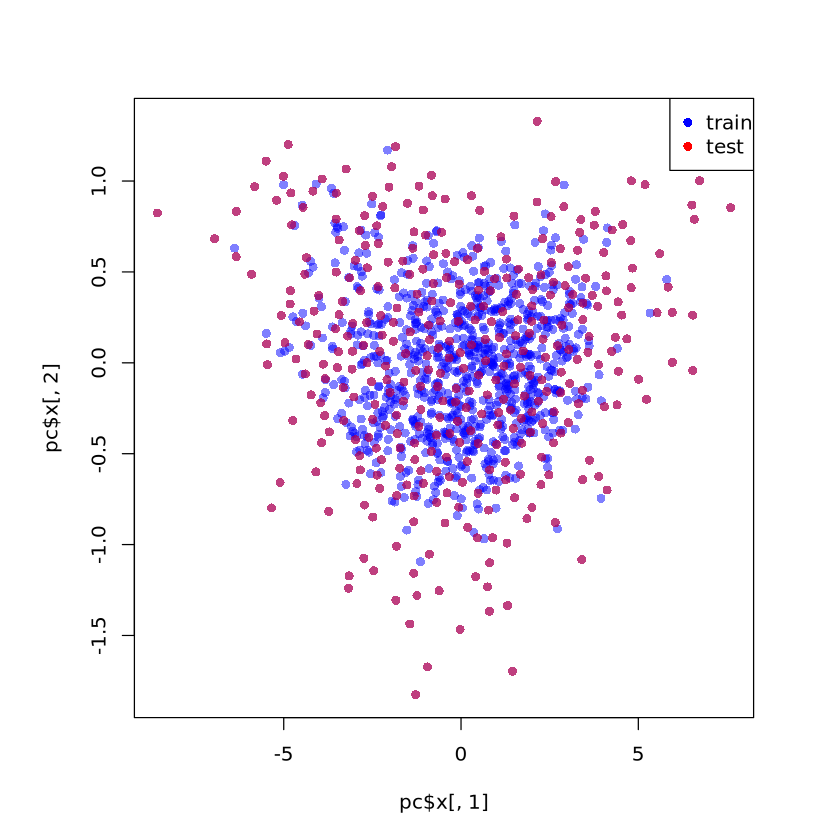

In [ ]:
nXdat<-nXr00

# size of test set:
# nt<-30
nt <- round(0.10 * nrow(nXdat))


# Kennard-Stone algorithm
split<-kenStone(X = nXdat, 
                k = nt, 
                metric="mahal",
                pc=0.95,   # based on PC feature space explaining 95% of overall variance of the spectra
                .center = TRUE,
                .scale = FALSE)


# which samples are defined as test set
test<-split$model

# which samples are defined as calibration set
train<-split$test

# Plot in PC feature space
pc<-prcomp(nXdat, center=T, scale. = F, rank. = 5)

par(pty="s")      # pty="s" ---> squared plot, regardless of the plot window size

matplot(pc$x[,1],   # scores of first PC
        pc$x[,2],   # scores of second PC
        pch=16,
        col=adjustcolor("blue", alpha.f=0.5))     # filled points

# adding test set
matpoints(pc$x[test,1], # only test set samples, 1st PC
          pc$x[test,2], # only test set samples, 2nd PC
          pch=16, 
          col=adjustcolor("red", alpha.f=0.5))

legend("topright", c("train", "test"), pch=16, col=c("blue", "red"))

In [13]:
###########################
### baseline PLS model: ###
###########################

# in the first step, we calculated a baseline predicion model using PLS regression 
# based on raw VNIR reflectance

# target variable: amount of clay minerals (in %)

# plsr() function requires input data as matrix
# nXdat<-nXr00

Ytrain <- as.matrix(lab$SOC[train])   # calibration set
Xtrain <- as.matrix(nXdat[train,])     # calibration set

# Model without cross validation
modf <- plsr(Ytrain~Xtrain,       # variables
             ncomp=20,  # max. number of latent variables to compute
             method="oscorespls",    # oscorespls = NIPALS = standard PLS
             validation="none")      # without any validation
summary(modf)

# Model with 10-fold cross validation
set.seed(123)
modcv <- plsr(Ytrain~Xtrain,        # variables
              ncomp=20,   # max. number of latent variables to compute
              method="oscorespls",     # oscorespls = NIPALS 
              validation="CV",   # with n-fold cross-validation
              segments=10)       # n of segments = 10 --> 10-fold CV
summary(modcv)

# RMSE of model fit
err_fit<-RMSEP(modf)

# RMSE of cross validation
err_modcv<-RMSEP(modcv)

# plot them together
plot(err_fit)       # RMSEcv of model fit
plot(err_modcv, add=T)# RMSEcv of cross validation - find optimal number of latent variables
# with increasing number of latent variables, PLS is able to explain an increasing amount of 
# variance of Y

# with cross validation, we can define the point where the model is overfitting, i.e. where the model
# uses sample specific noise to explain Y, which results in an increase of RMSE in the test set


ERROR: Error in plsr(Ytrain ~ Xtrain, ncomp = 20, method = "oscorespls", validation = "none"): could not find function "plsr"


In [ ]:
################
# set optimal number of latent variables here, defined as minimum RMSE:
onc <- which.min(err_modcv$val[1,,]) - 1  # - 1 to compensate to remove the RMSE of the intercept

# Inspection of regression coefficients
par(pty="m") # pty="m" --> maximizing plot to plot window
matplot(wl, modcv$coefficients[,,onc], type="l", lty=1,
        xlab="wavelengths (nm)", ylab="PLS coefficients")
axis(1, seq(500,2500,100), labels = NA)
abline(h=0, lty=2, col="gray")
# we clearly see the most important wavelengths e.g. around 1420, 1905, 2220 nm,
# which are caused by water and hydrogen absorption and can be indirectly linked 
# to clay mineral absorption in soil samples

#######
# evaluation of cross validated results
# scatter plot of observed vs predicted values
par(pty="s")

# --------- Änderung 1: Matrix → Vektor für Ytrain ---------
Yobs <- as.vector(Ytrain)  # <--- diese Zeile ersetzt direkt Ytrain
Ycv <- as.vector(modcv$validation$pred[,,onc])  # <--- Slice des Arrays in Vektor umwandeln

matplot(Yobs, Ycv, xlab="observed values", ylab="predicted values", pch=16)  # hier nur Yobs und Ycv
# adding a 1:1 line
abline(0,1, lty=2, col="darkgrey")

# validation metrics:
np <- length(Yobs)  # <--- Länge des Vektors statt nrow(Yobs)



# calculation of R²:
SST<-sum((Yobs-mean(Yobs))^2)        
SSE<-sum((Ycv-Yobs)^2)
R2<-round(1-(SSE/SST), digits=2)

# calculation of RMSE
RMSE<-round(sqrt(sum((Ycv-Yobs)^2)/np), digits=2)

# Calculation of RPD
RPD<-round(sd(Yobs)/RMSE, digits=2)

print(c(R2, RMSE, RPD))

# Text für die Legende
legend_text <- c(paste("R²_cv =", R2),
                 paste("RMSE_cv =", RMSE),
                 paste("RPD_cv =", RPD))

# Legende oben links hinzufügen
legend("topleft", legend=legend_text, bty="n", cex=1.2)


ERROR: Error: object 'err_modcv' not found


[1] 0.17

[1] 27.44

[1] 1.11

[1]  0.17 27.44  1.11


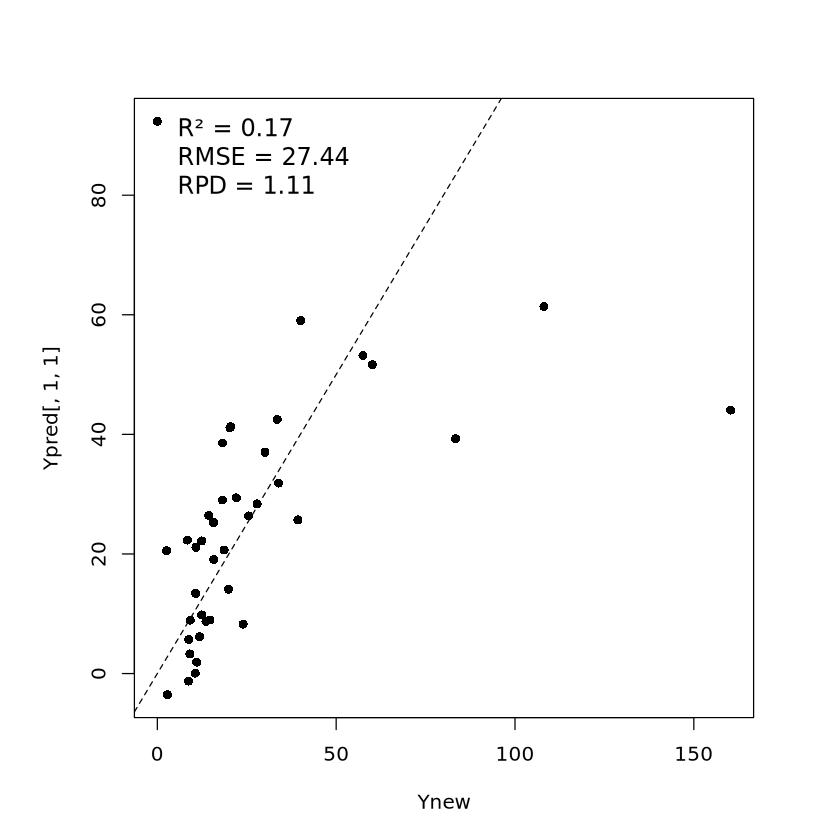

In [ ]:
###############################
### Prediction on test set: ###
###############################

Ynew <- as.matrix(lab$SOC[test])  # test set
Xnew <- as.matrix(nXdat[test,])    # test set

# actual prediction:
Ypred <- predict(object=modcv,    # prediction based on model
                 ncomp=onc,       # optimal number of latent variables
                 newdata = Xnew)  # new, 'unknown' data

# Scatter plot:
par(pty="s")
matplot(Ynew, 
        Ypred[,1,1], 
        pch=16)
abline(0,1, lty=2)   # 1:1 line

# validation metrics:
np<-nrow(Ynew)     # number of predictions

# calculation of R²:
SST<-sum((Ynew-mean(Ynew))^2)        
SSE<-sum((Ynew-Ypred[,1,1])^2)
R2<-round(1-(SSE/SST), digits=2)
R2

# calculation of RMSE
RMSE<-round(sqrt(sum((Ypred[,1,1]-Ynew)^2)/np), digits=2)
RMSE

# Calculation of RPD
RPD<-round(sd(Ynew)/RMSE, digits=2)
RPD

print(c(R2, RMSE, RPD))

# text for the legend
legend_text <- c(paste("R² =", R2),
                 paste("RMSE =", RMSE),
                 paste("RPD =", RPD))

# legend
legend("topleft", legend=legend_text, bty="n", cex=1.2)

In [ ]:
################################################################################
#### Alternative: train() function in the caret package: ####
#############################################################

# In the following, we are using the train() function of the caret package to repeat 
# the PLS model
# The advantage is that the train() function provides a unified and systematic 
# framework for model training, validation, and optimization, including multiple 
# regression and classification methods (e.g. linear regression, random forest, SVM, etc.).

# plsr() function requires input data as matrix
nXdat<-nXr00

# dependent variable and predictors
Ytrain <- as.matrix(lab$SOC[train])   # training set
Xtrain <- as.matrix(nXdat[train,])     # training set 

# combine to a data frame
traindat <- data.frame(target = Ytrain, Xtrain)

# Set up a control object for cross-validation (part of the train function)
set.seed(123)
control <- trainControl(method = "cv", number = 10, savePredictions = "final")

# Set up a tuning object for grid search of optimal model parameters (part of the train function)
tuneGrid = expand.grid(ncomp = 1:20) # Specify a grid of latent variables to tune

# Partial Least Squares Regression (PLSR)
set.seed(123)
plsr_model <- train(target~ .,
                    data = traindat,
                    method = "pls",
                    preProcess = c("center"),
                    trControl = control,
                    tuneGrid = tuneGrid)

print(plsr_model)
summary(plsr_model)

Partial Least Squares 

1140 samples
1000 predictors

Pre-processing: centered (1000) 
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 1026, 1027, 1027, 1026, 1026, 1027, ... 
Resampling results across tuning parameters:

  ncomp  RMSE      Rsquared   MAE      
   1     18.21079  0.1046503  10.989802
   2     17.14357  0.2142986  10.410903
   3     16.19348  0.3069925  10.003042
   4     15.62334  0.3553599   9.852761
   5     14.38851  0.4575836   9.101803
   6     13.64026  0.5123990   8.862514
   7     12.98042  0.5615654   8.339497
   8     12.30047  0.6114302   7.973147
   9     11.91774  0.6372740   7.497462
  10     11.33724  0.6738574   7.186937
  11     11.03277  0.6909373   6.839840
  12     10.85391  0.7013581   6.738017
  13     10.82083  0.7050520   6.688116
  14     10.78847  0.7082224   6.639240
  15     10.83452  0.7056154   6.661602
  16     10.96069  0.6994047   6.689252
  17     10.98304  0.6976060   6.632716
  18     11.01664  0.6958209   6.624431
  

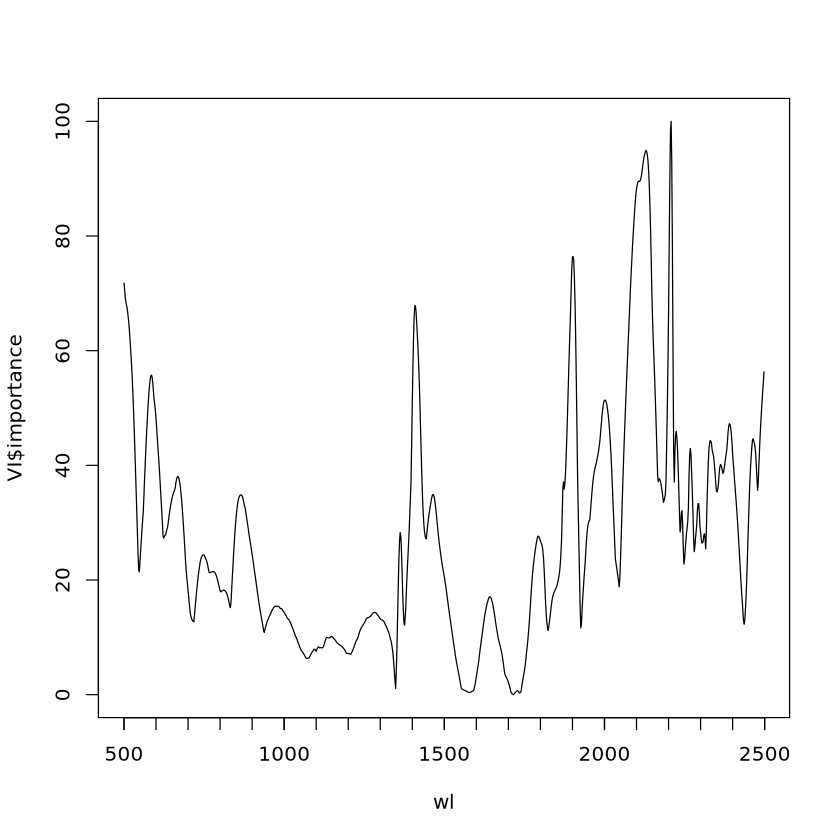

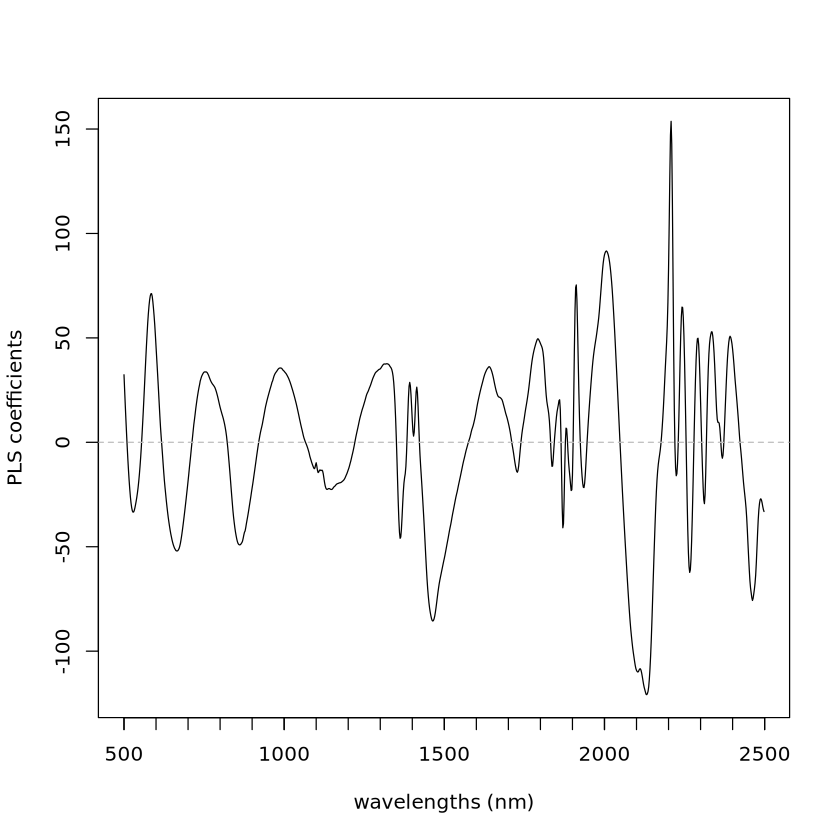

[1] 0.17

[1] 27.44

[1] 1.11

[1]  0.17 27.44  1.11


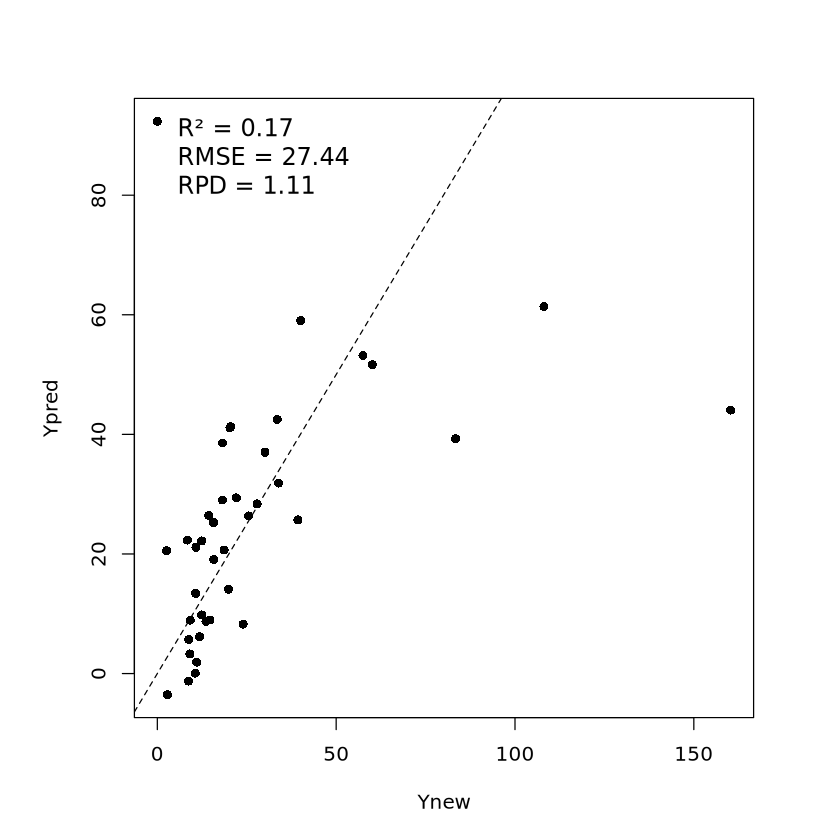

In [ ]:
# Partial Least Squares: the variable importance measure here is based on 
# weighted sums of the absolute regression coefficients. 
# The weights are a function of the reduction of the sums of squares across 
# the number of PLS components and are computed separately for each outcome. 
# Therefore, the contribution of the coefficients are weighted proportionally 
# to the reduction in the sums of squares.

VI<-varImp(plsr_model)
matplot(wl, VI$importance, type="l", lty=1)
axis(1, seq(500,2500,100), labels = NA)

# regression coefficients from train object:
par(pty="m")          # pty="m" --> maximizing plot to plot window
matplot(wl, coef(plsr_model$finalModel, ncomp=plsr_model$bestTune$ncomp), 
        type="l", lty=1,
        xlab="wavelengths (nm)", ylab="PLS coefficients")
axis(1, seq(500,2500,100), labels = NA)
abline(h=0, lty=2, col="gray")


#############################################
# prediction of test set:

Ynew <- as.matrix(lab$SOC[test])  # test set
Xnew <- as.matrix(nXdat[test,])    # test set

# this way, the optimal model (best fit) is used for prediction
Ypred<- predict(plsr_model,
                newdata=Xnew)

# adjusting the optimal model is possible:

# Apply same preprocessing to the new data
#Xnew_prep <- predict(plsr_model$preProcess, newdata=Xnew)

# specifiying the required model configuration:
# Ypred <- predict(object=plsr_model$finalModel,    # prediction based on model
#                  ncomp=12,
#                  newdata  = Xnew_prep)  # new, 'unknown' data

# Scatter plot:
par(pty="s")
matplot(Ynew, 
        Ypred, 
        pch=16)
abline(0,1, lty=2)   # 1:1 line

# validation metrics:
np<-nrow(Ynew)     # number of predictions

# calculation of R²:
SST<-sum((Ynew-mean(Ynew))^2)        
SSE<-sum((Ynew-Ypred)^2)
R2<-round(1-(SSE/SST), digits=2)
R2

# calculation of RMSE
RMSE<-round(sqrt(sum((Ypred-Ynew)^2)/np), digits=2)
RMSE

# Calculation of RPD
RPD<-round(sd(Ynew)/RMSE, digits=2)
RPD

print(c(R2, RMSE, RPD))

# text for the legend
legend_text <- c(paste("R² =", R2),
                 paste("RMSE =", RMSE),
                 paste("RPD =", RPD))

# legend
legend("topleft", legend=legend_text, bty="n", cex=1.2)